In [1]:
! git clone https://github.com/George-Malak/Aegis-AI-Violence-Detection-System.git

Cloning into 'Aegis-AI-Violence-Detection-System'...
remote: Enumerating objects: 371, done.
remote: Counting objects: 100% (371/371), done.
remote: Compressing objects: 100% (280/280), done.
remote: Total 371 (delta 131), reused 252 (delta 67), pack-reused 0 (from 0)
Receiving objects: 100% (371/371), 7.16 MiB | 21.50 MiB/s, done.
Resolving deltas: 100% (131/131), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import cv2
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
def extract_dataset_info(base_dir):
    data_list = []

    splits = ['Train', 'Val', 'Test']

    for split in splits:
        split_path = os.path.join(base_dir, split)
        if not os.path.exists(split_path):
            continue

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)
            if not os.path.isdir(class_path):
                continue

            for video_name in os.listdir(class_path):
                if video_name.endswith(('.mp4', '.avi', '.mkv', '.mov')):
                    video_path = os.path.join(class_path, video_name)

                    cap = cv2.VideoCapture(video_path)
                    fps = cap.get(cv2.CAP_PROP_FPS)
                    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
                    width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
                    height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
                    duration = frame_count / fps if fps > 0 else 0
                    cap.release()

                    source = 'Arabic' if 'arabic' in video_name.lower() else 'UCF'

                    data_list.append({
                        'Video_Name': video_name,
                        'Split': split,          # train, val, test
                        'Class': class_name,      # violence, non-violence
                        'Source': source,        # Arabic, UCF
                        'Duration_Sec': duration,
                        'Total_Frames': frame_count,
                        'FPS': fps,
                        'Resolution': f"{int(width)}x{int(height)}"
                    })

    return pd.DataFrame(data_list)

In [7]:
ROOT_DIR = Path('/content/drive/MyDrive/DEPI Project').resolve()
df = extract_dataset_info(ROOT_DIR)

df.head()


,Video_Name,Split,Class,Source,Duration_Sec,Total_Frames,FPS,Resolution
0,Arrest002_x264.mp4,Train,Arrest,UCF,59.666667,1790.0,30.0,320x240
1,Arrest004_x264.mp4,Train,Arrest,UCF,120.100000,3603.0,30.0,320x240
2,Arrest005_x264.mp4,Train,Arrest,UCF,122.833333,3685.0,30.0,320x240
3,Arrest006_x264.mp4,Train,Arrest,UCF,103.000000,3090.0,30.0,320x240
4,Arrest012_x264.mp4,Train,Arrest,UCF,538.700000,16161.0,30.0,320x240


In [8]:
print("--- # of Videos of each stage ---")
print(df['Split'].value_counts())

--- # of Videos of each stage ---
Split
Train    5464
Test      166
Val       145
Name: count, dtype: int64


In [9]:
print("\n--- Details of Classes ---")
print(df.groupby(['Split', 'Class', 'Source']).size().unstack(fill_value=0))


--- Details of Classes ---
Source               Arabic  UCF
Split Class                     
Test  Abuse               0    2
      Arrest              0    5
      Arson               0    9
      Assault             0    3
      Burglary            0   13
      Explosion           0   21
      Fighting            0    5
      Normal              0   26
      RoadAccidents       0   23
      Robbery             0    5
      Shooting            0   23
      Shoplifting         0   21
      Stealing            0    5
      Vandalism           0    5
Train Abuse               0  484
      Arrest            230   38
      Arson             290   35
      Assault           214   40
      Burglary          396   74
      Explosion         194   24
      Fighting          422   38
      Normal           1222  180
      RoadAccidents      62  107
      Robbery           302  123
      Shooting          180   29
      Shoplifting       166   25
      Stealing          262   82
      Vandalism

<Figure size 1400x600 with 0 Axes>

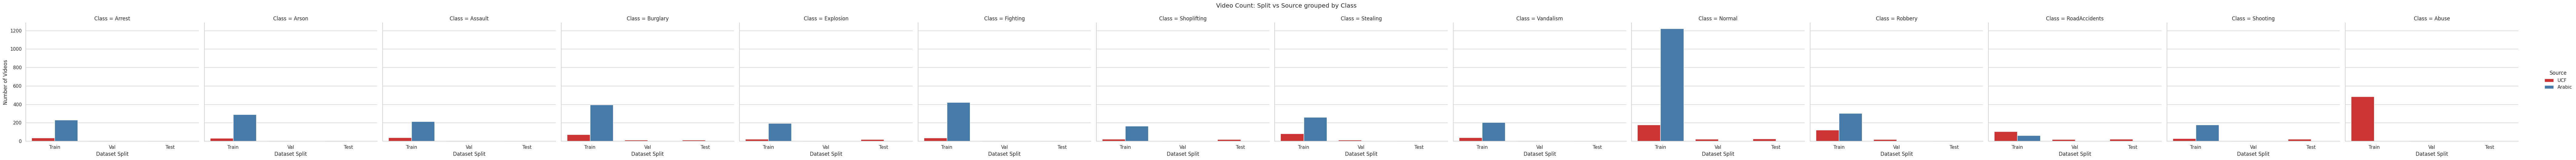

In [10]:
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df, x="Split", hue="Source", col="Class",
    kind="count", palette="Set1", height=5, aspect=1.2
)
g.set_axis_labels("Dataset Split", "Number of Videos")
g.fig.suptitle("Video Count: Split vs Source grouped by Class", y=1.05)
plt.show()

/tmp/ipykernel_418/1332765200.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Source", y="Total_Frames", palette="Pastel1")


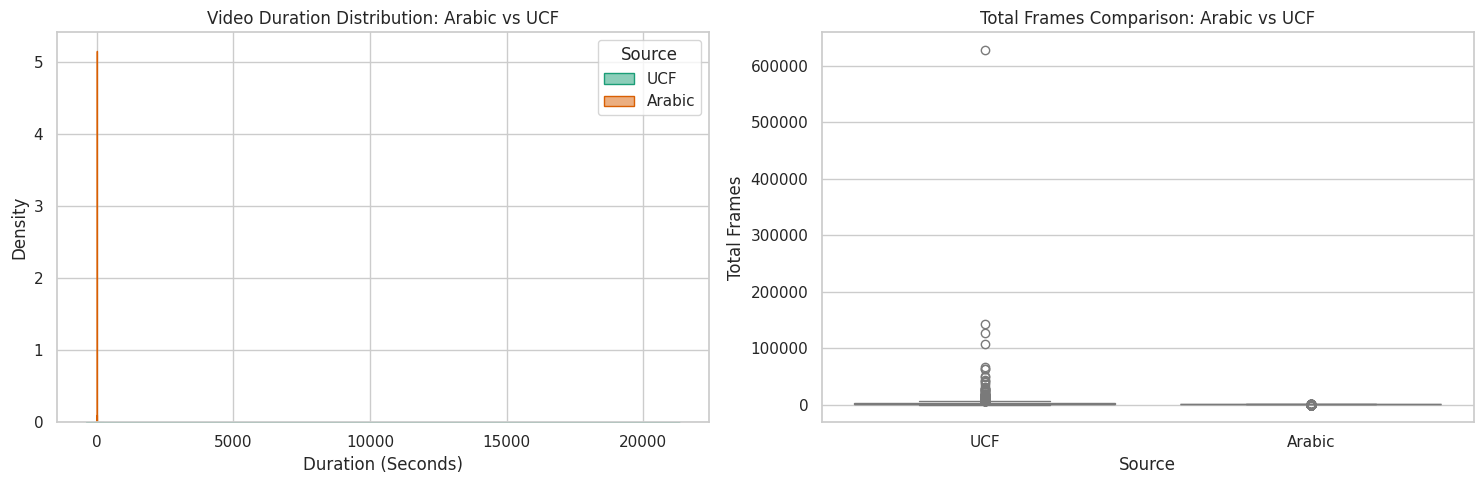

In [11]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x="Duration_Sec", hue="Source", fill=True, common_norm=False, alpha=0.5, palette="Dark2")
plt.title("Video Duration Distribution: Arabic vs UCF")
plt.xlabel("Duration (Seconds)")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="Source", y="Total_Frames", palette="Pastel1")
plt.title("Total Frames Comparison: Arabic vs UCF")
plt.ylabel("Total Frames")

plt.tight_layout()
plt.show()

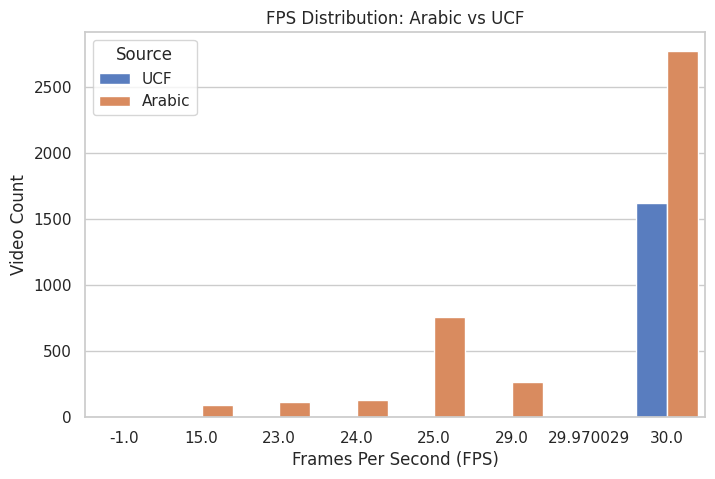

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="FPS", hue="Source", palette="muted")
plt.title("FPS Distribution: Arabic vs UCF")
plt.xlabel("Frames Per Second (FPS)")
plt.ylabel("Video Count")
plt.show()

In [13]:
df['Width'] = df['Resolution'].apply(lambda x: int(x.split('x')[0]))
df['Height'] = df['Resolution'].apply(lambda x: int(x.split('x')[1]))

df['Aspect_Ratio'] = (df['Width'] / df['Height']).round(2)

def classify_resolution(width):
    if width >= 1920: return 'Full HD (1080p)'
    elif width >= 1280: return 'HD (720p)'
    else: return 'SD (Low Quality)'

df['Quality_Class'] = df['Width'].apply(classify_resolution)

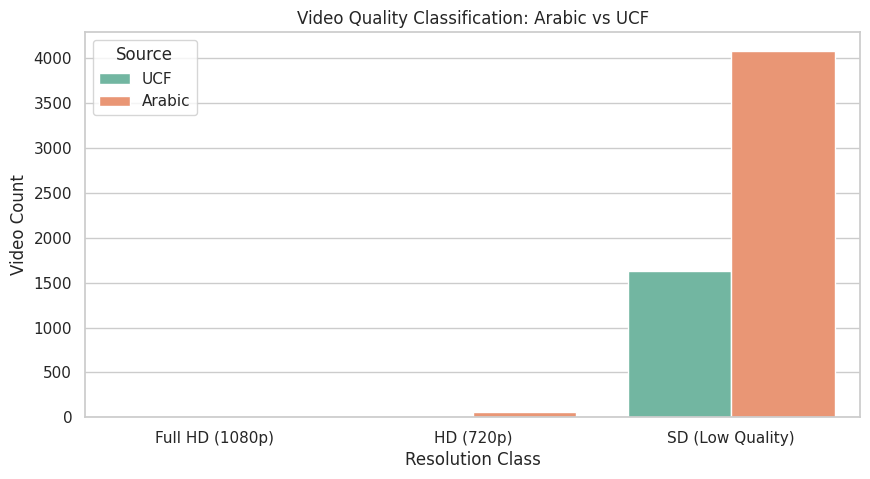

In [14]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Quality_Class", hue="Source", palette="Set2",
              order=['Full HD (1080p)', 'HD (720p)', 'SD (Low Quality)'])
plt.title("Video Quality Classification: Arabic vs UCF")
plt.xlabel("Resolution Class")
plt.ylabel("Video Count")
plt.show()

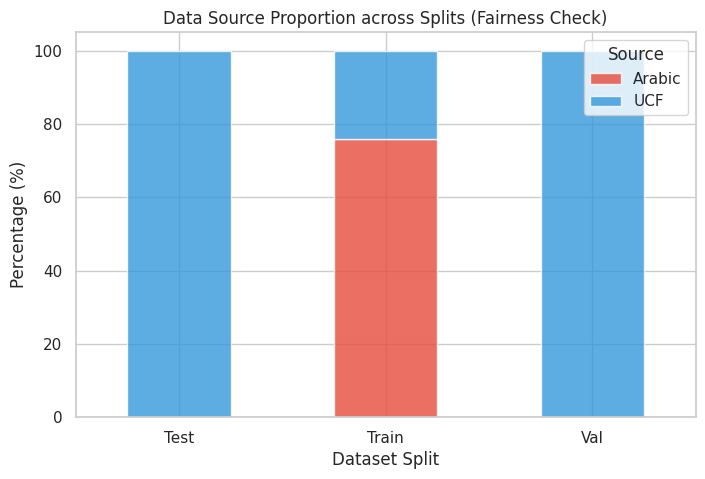

In [15]:
split_counts = df.groupby(['Split', 'Source']).size().unstack().fillna(0)
split_percents = split_counts.div(split_counts.sum(axis=1), axis=0) * 100

split_percents.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#e74c3c', '#3498db'], alpha=0.8)
plt.title("Data Source Proportion across Splits (Fairness Check)")
plt.ylabel("Percentage (%)")
plt.xlabel("Dataset Split")
plt.legend(title="Source")
plt.xticks(rotation=0)
plt.show()

In [16]:
print("--- Statics on video (per second) ---")
print(df['Duration_Sec'].describe())

--- Statics on video (per second) ---
count     5775.000000
mean        33.049302
std        306.367897
min          0.000000
25%          3.000000
50%          3.000000
75%         20.000000
max      20934.000000
Name: Duration_Sec, dtype: float64


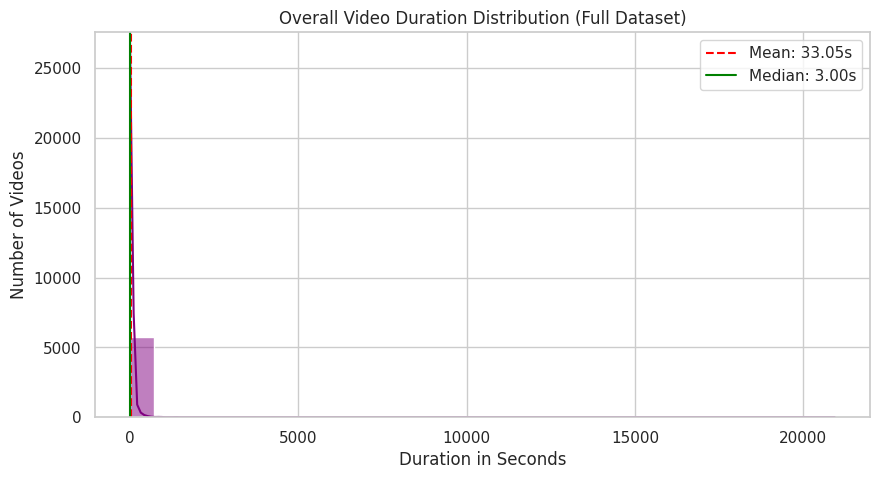

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Duration_Sec", kde=True, color="purple", bins=30)

plt.axvline(df['Duration_Sec'].mean(), color='red', linestyle='--', label=f"Mean: {df['Duration_Sec'].mean():.2f}s")
plt.axvline(df['Duration_Sec'].median(), color='green', linestyle='-', label=f"Median: {df['Duration_Sec'].median():.2f}s")

plt.title("Overall Video Duration Distribution (Full Dataset)")
plt.xlabel("Duration in Seconds")
plt.ylabel("Number of Videos")
plt.legend()
plt.show()

/tmp/ipykernel_418/292136527.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


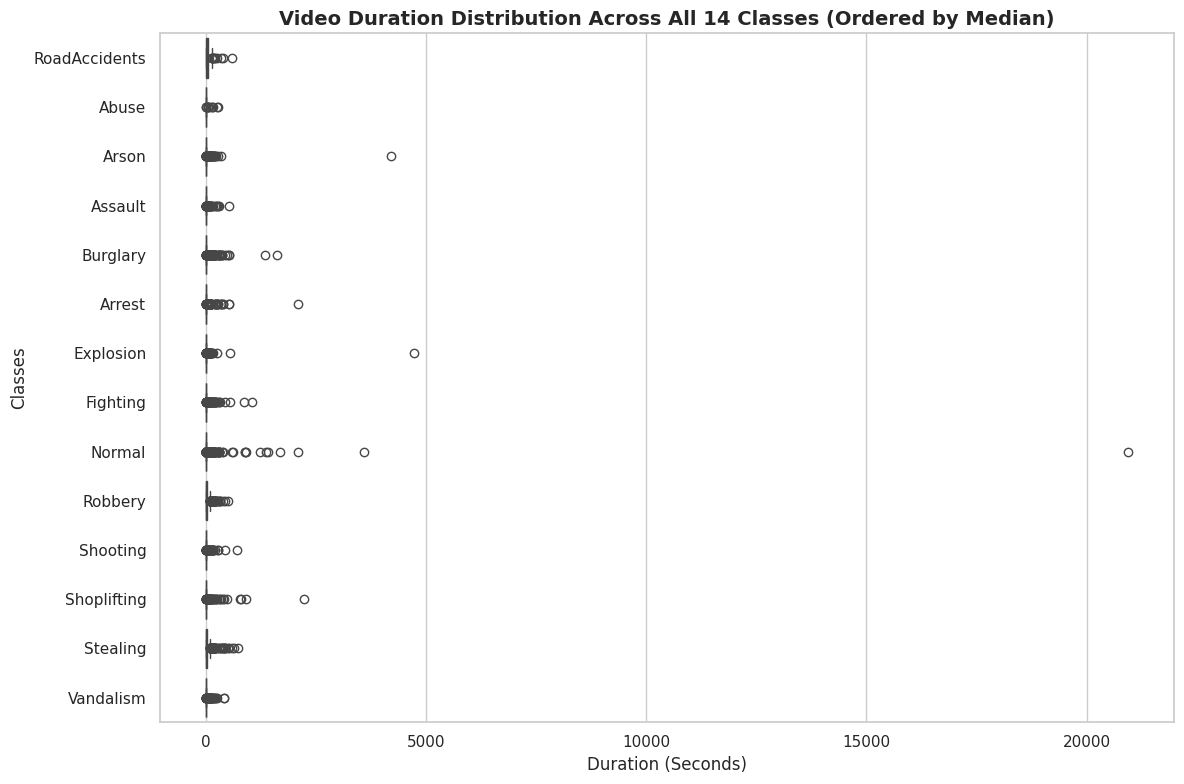

In [19]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

class_order = df.groupby("Class")["Duration_Sec"].median().sort_values(ascending=False).index

sns.boxplot(
    data=df,
    y="Class",
    x="Duration_Sec",
    palette="Spectral",
    order=class_order
)

plt.title("Video Duration Distribution Across All 14 Classes (Ordered by Median)", fontsize=14, fontweight='bold')
plt.xlabel("Duration (Seconds)", fontsize=12)
plt.ylabel("Classes", fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
df['Duration_Min'] = df['Duration_Sec'] / 60

total_time_pivot = df.pivot_table(
    values='Duration_Min',
    index='Class',
    columns='Split',
    aggfunc='sum',
    fill_value=0
)

total_time_pivot['Total_Dataset_Minutes'] = total_time_pivot.sum(axis=1)
total_time_pivot = total_time_pivot.sort_values(by='Total_Dataset_Minutes', ascending=False)

print("--- total duration for each class ---")
display(total_time_pivot.round(2))

--- total duration for each class ---


Split,Test,Train,Val,Total_Dataset_Minutes
Class,,,,
Normal,98.50,449.76,380.57,928.82
Burglary,42.51,195.09,43.76,281.36
Stealing,11.01,239.93,24.28,275.21
Robbery,4.63,210.16,34.87,249.66
Shoplifting,42.30,117.61,28.30,188.21
Abuse,1.64,161.00,18.36,181.00
Arrest,18.68,146.31,11.47,176.46
Arson,15.49,134.46,14.88,164.84
Fighting,6.83,145.85,12.01,164.69


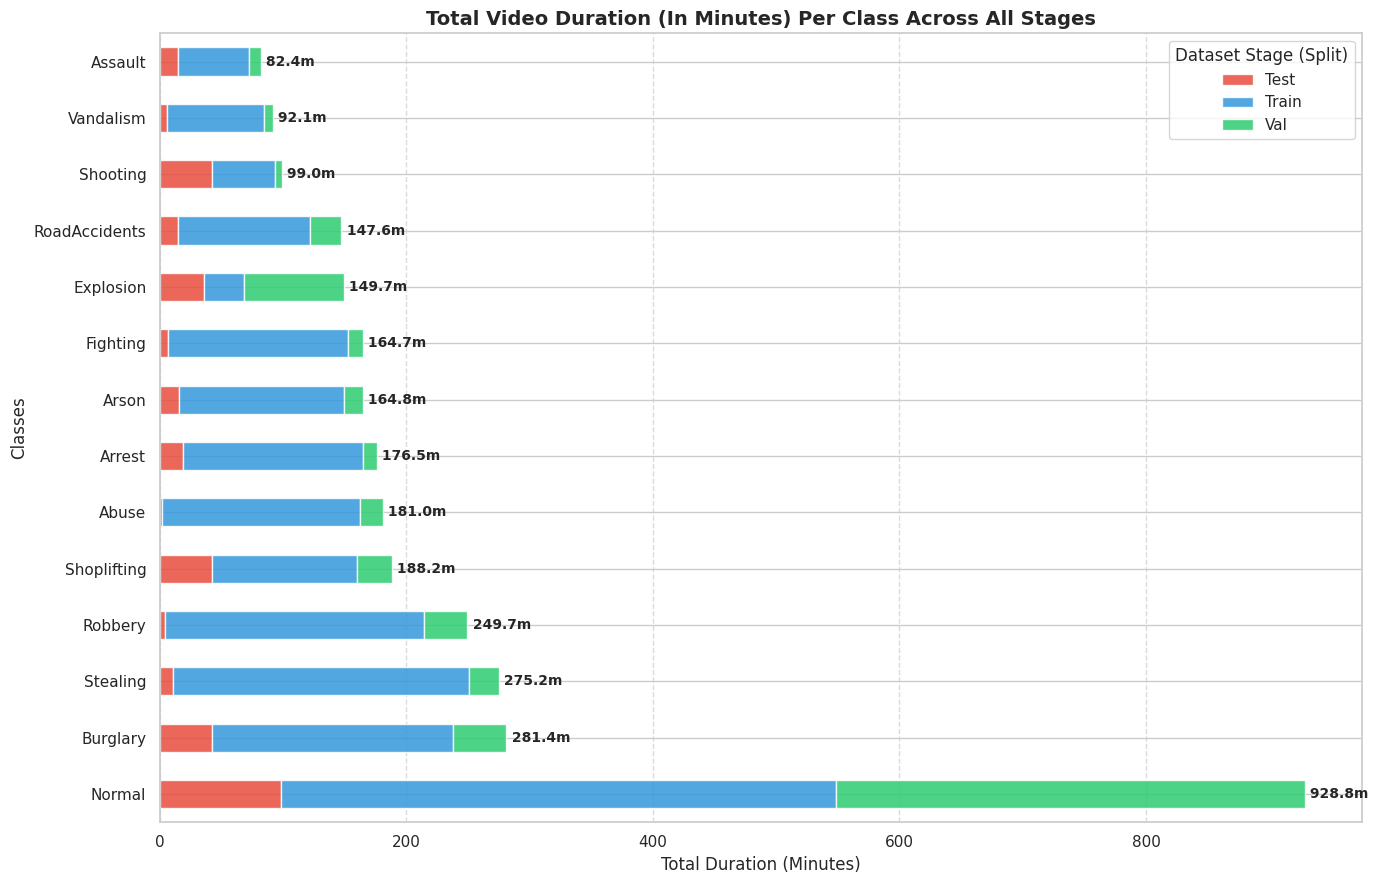

In [21]:
plot_data = total_time_pivot.drop(columns=['Total_Dataset_Minutes'])

ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 9),
    color=['#e74c3c', '#3498db', '#2ecc71'],
    alpha=0.85
)

plt.title("Total Video Duration (In Minutes) Per Class Across All Stages", fontsize=14, fontweight='bold')
plt.xlabel("Total Duration (Minutes)", fontsize=12)
plt.ylabel("Classes", fontsize=12)
plt.legend(title="Dataset Stage (Split)", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, (idx, row) in enumerate(total_time_pivot.iterrows()):
    total_min = row['Total_Dataset_Minutes']
    ax.text(total_min + 0.1, i, f" {total_min:.1f}m", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()